In [1]:
from utils_ml import * 

In [2]:
# Load and concatenate all features
file_prefix = "dataExt/P"
file_suffix = "_intensity.pkl"
num_files = 35

old_label_arr = np.array([np.tile(i,np.load(f"{file_prefix}{0:02d}{file_suffix}", allow_pickle=True).shape[0]) for i in np.arange(num_files)]).flatten()

# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}

new_label_arr = convert_labels(old_label_arr, class_to_poles)

print("Old Labels:\n", old_label_arr)
print("New Labels:\n", new_label_arr)

# Later, load the saved array in memory-mapped mode
features_memmap = np.load('dataExt/features_filtered.npy', mmap_mode='r+')

X_train_new, X_test_new, y_train, y_test = train_test_split(features_memmap, new_label_arr, test_size=0.1, random_state=42)

Old Labels:
 [ 0  0  0 ... 34 34 34]
New Labels:
 [[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [1 1 2]
 [1 1 2]
 [1 1 2]]


In [3]:
# Train Pool for CatBoost (multi-output regression requires separate models per target)
models = []
preds = []
data_uncertainty = []
knowledge_uncertainty = []

for i in range(y_train.shape[1]):
    train_pool = Pool(X_train_new, y_train[:, i])
    val_pool = Pool(X_test_new, y_test[:, i])

    model = CatBoostRegressor(
        iterations=2000,
        loss_function='RMSEWithUncertainty',
        early_stopping_rounds=20,
        bootstrap_type='Bernoulli',
        random_seed=0,
        verbose=100
    )
    model.fit(train_pool, eval_set=val_pool, use_best_model=False)
    models.append(model)

    # Generate predictions with uncertainty
    pred = model.virtual_ensembles_predict(X_test_new, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds.append(pred[:, 0])  # Mean predictions
    data_uncertainty.append(pred[:, 2])  # Data uncertainty
    knowledge_uncertainty.append(pred[:, 1])  # Knowledge uncertainty

# Convert lists to arrays for easier manipulation
preds = np.column_stack(preds)
data_uncertainty = np.column_stack(data_uncertainty)
knowledge_uncertainty = np.column_stack(knowledge_uncertainty)


0:	learn: 1.4512054	test: 1.4542096	best: 1.4542096 (0)	total: 270ms	remaining: 9m
100:	learn: -0.1881693	test: -0.1883897	best: -0.1883897 (100)	total: 20.5s	remaining: 6m 25s
200:	learn: -0.6409284	test: -0.6342568	best: -0.6342568 (200)	total: 40.8s	remaining: 6m 4s
300:	learn: -0.7958290	test: -0.7806834	best: -0.7806834 (300)	total: 1m	remaining: 5m 43s
400:	learn: -0.8524865	test: -0.8323696	best: -0.8323696 (400)	total: 1m 21s	remaining: 5m 24s
500:	learn: -0.9162733	test: -0.8932075	best: -0.8932075 (500)	total: 1m 41s	remaining: 5m 2s
600:	learn: -0.9661230	test: -0.9395495	best: -0.9395495 (600)	total: 1m 59s	remaining: 4m 39s
700:	learn: -0.9962424	test: -0.9663784	best: -0.9663784 (700)	total: 2m 18s	remaining: 4m 15s
800:	learn: -1.0221395	test: -0.9896838	best: -0.9897147 (799)	total: 2m 36s	remaining: 3m 53s
900:	learn: -1.0477223	test: -1.0123930	best: -1.0134880 (898)	total: 2m 54s	remaining: 3m 33s
1000:	learn: -1.0813057	test: -1.0434647	best: -1.0434647 (1000)	total

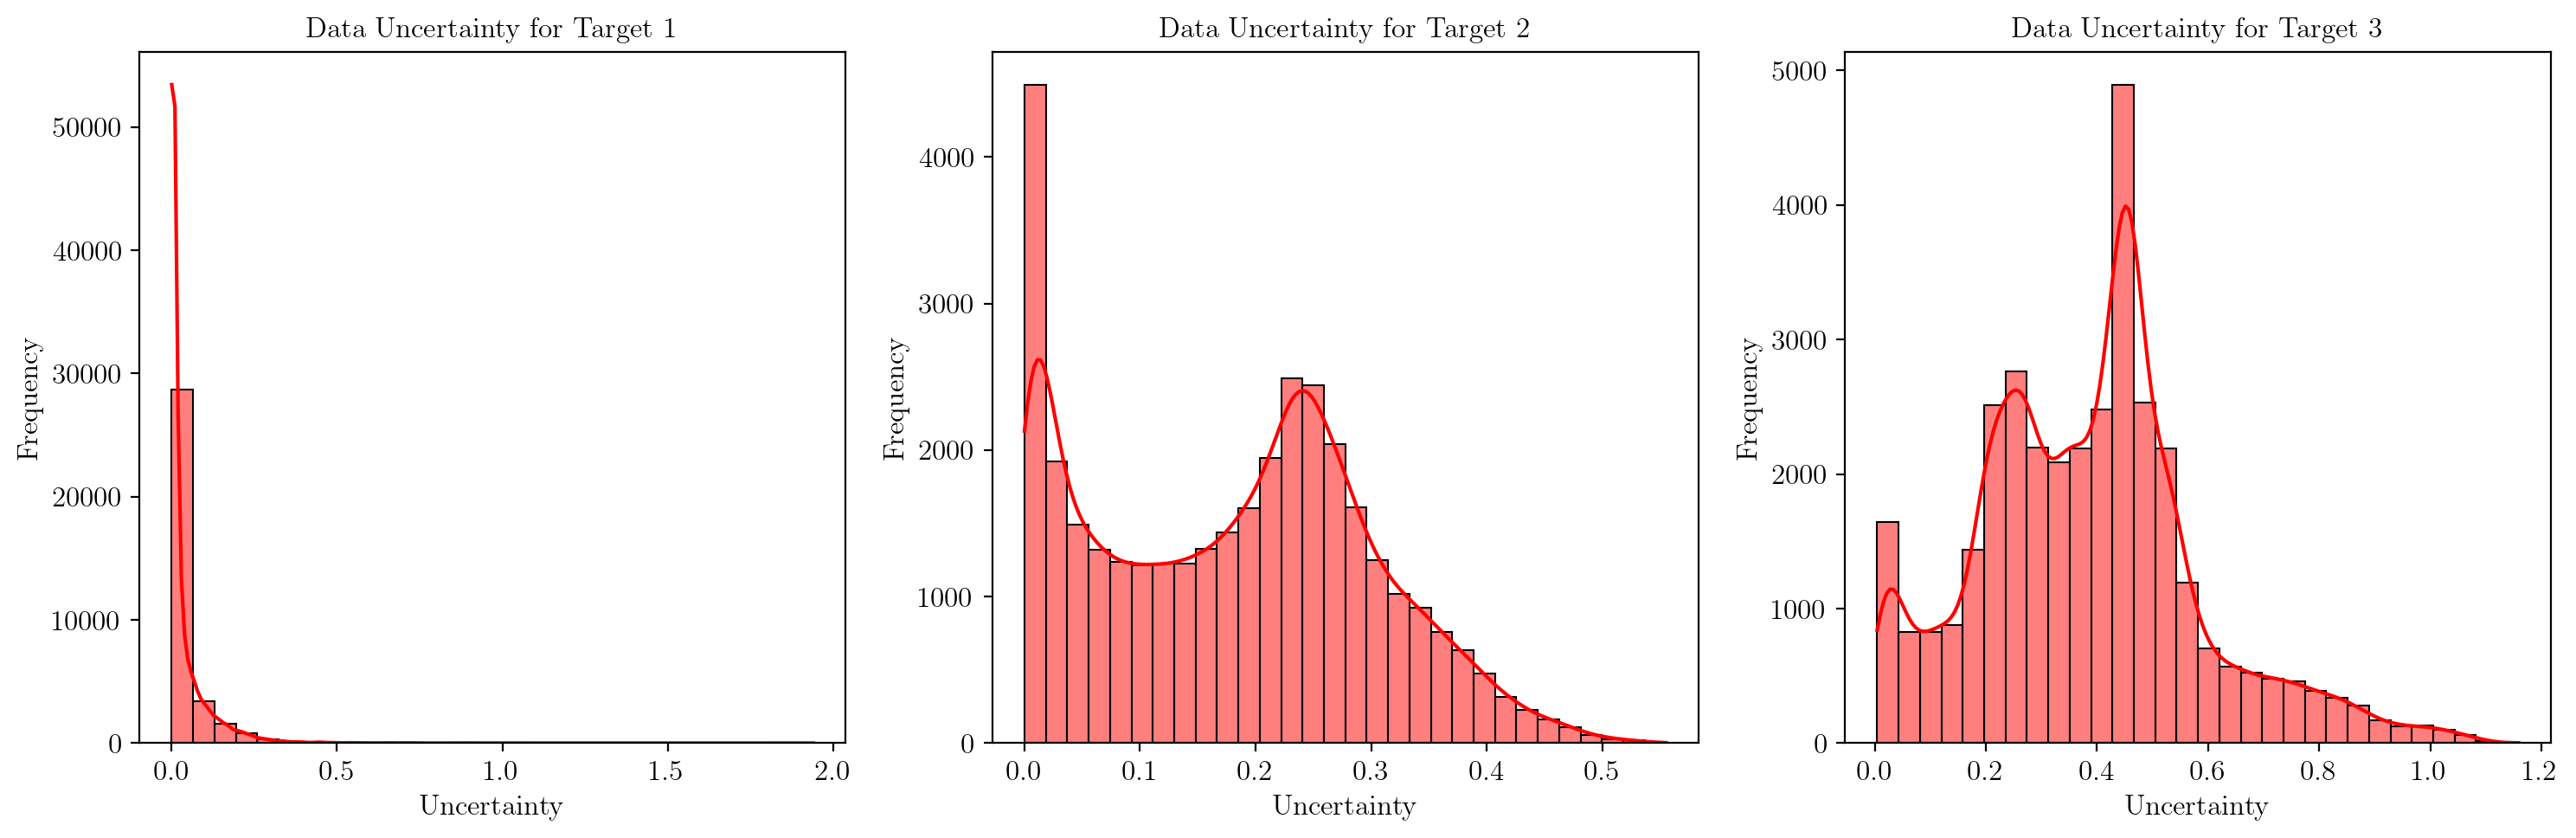

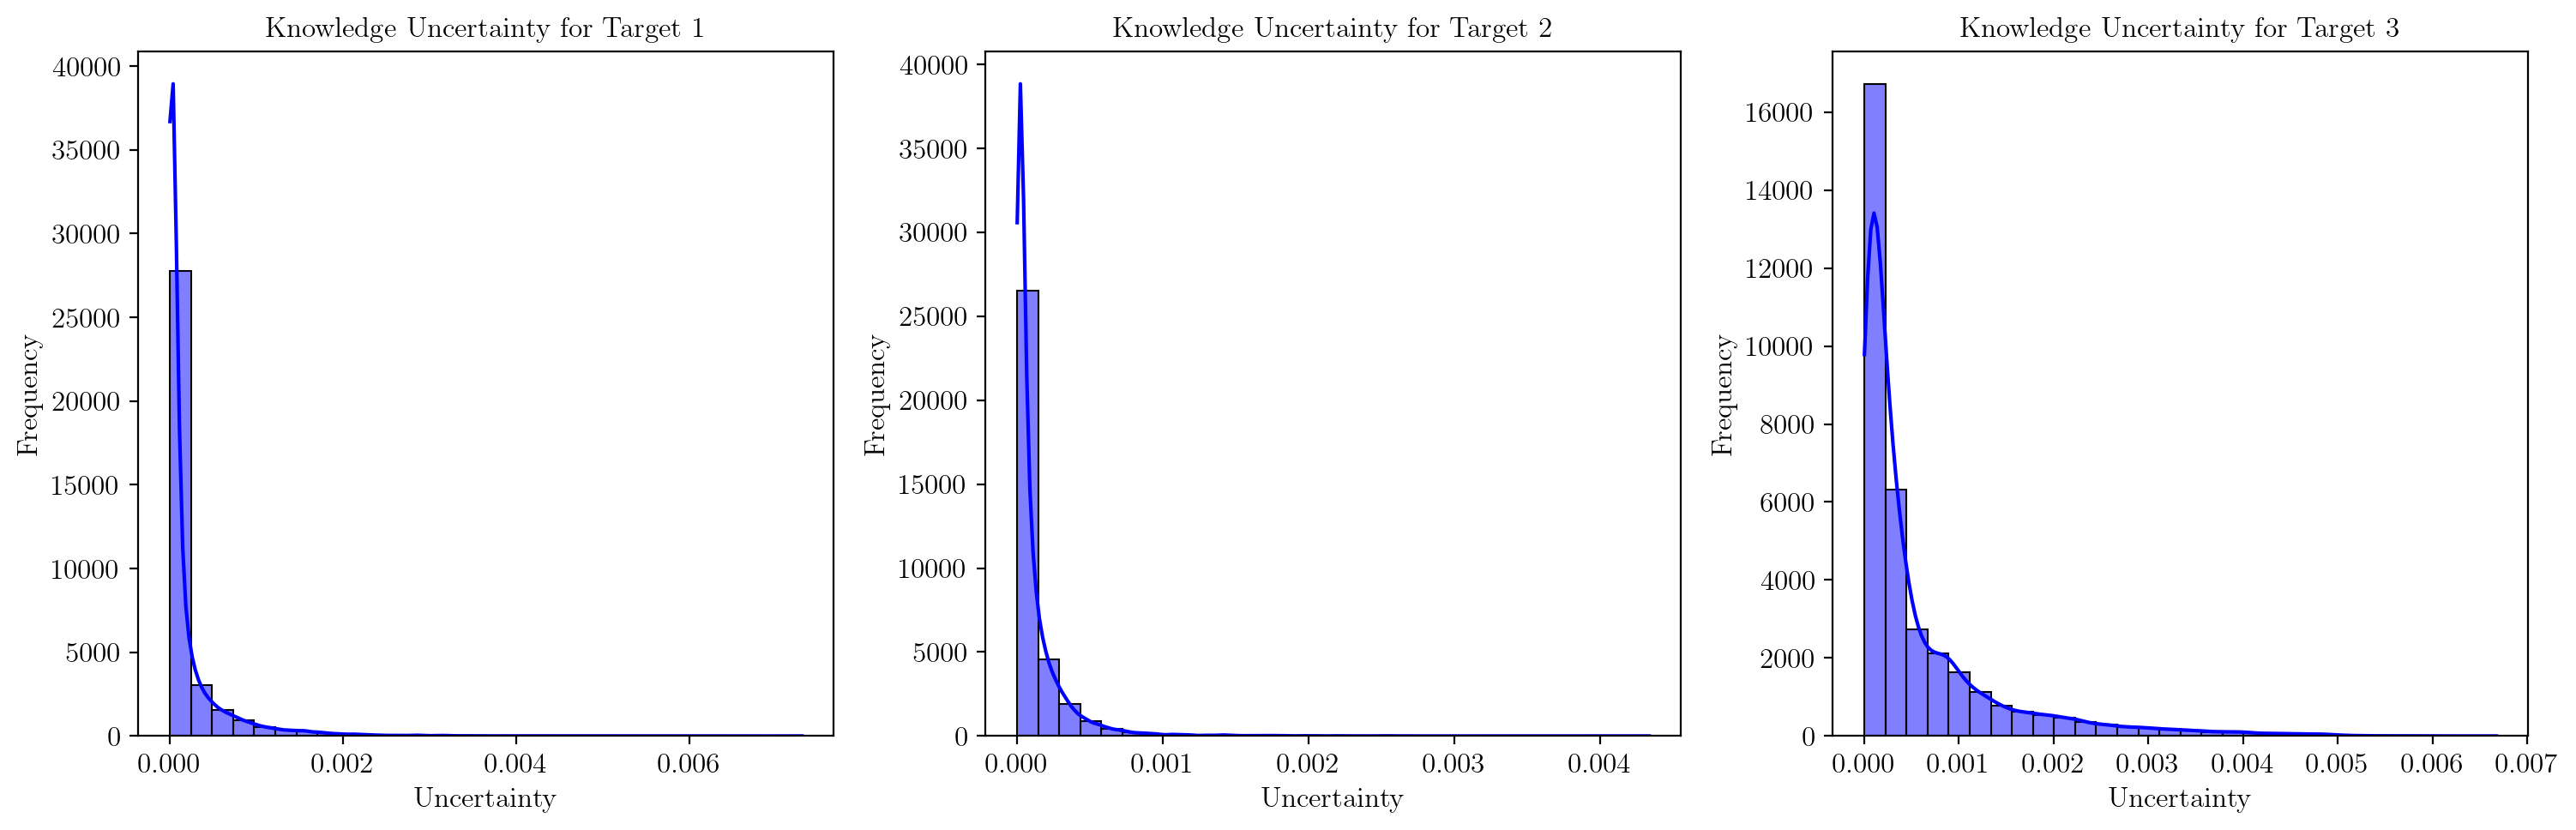

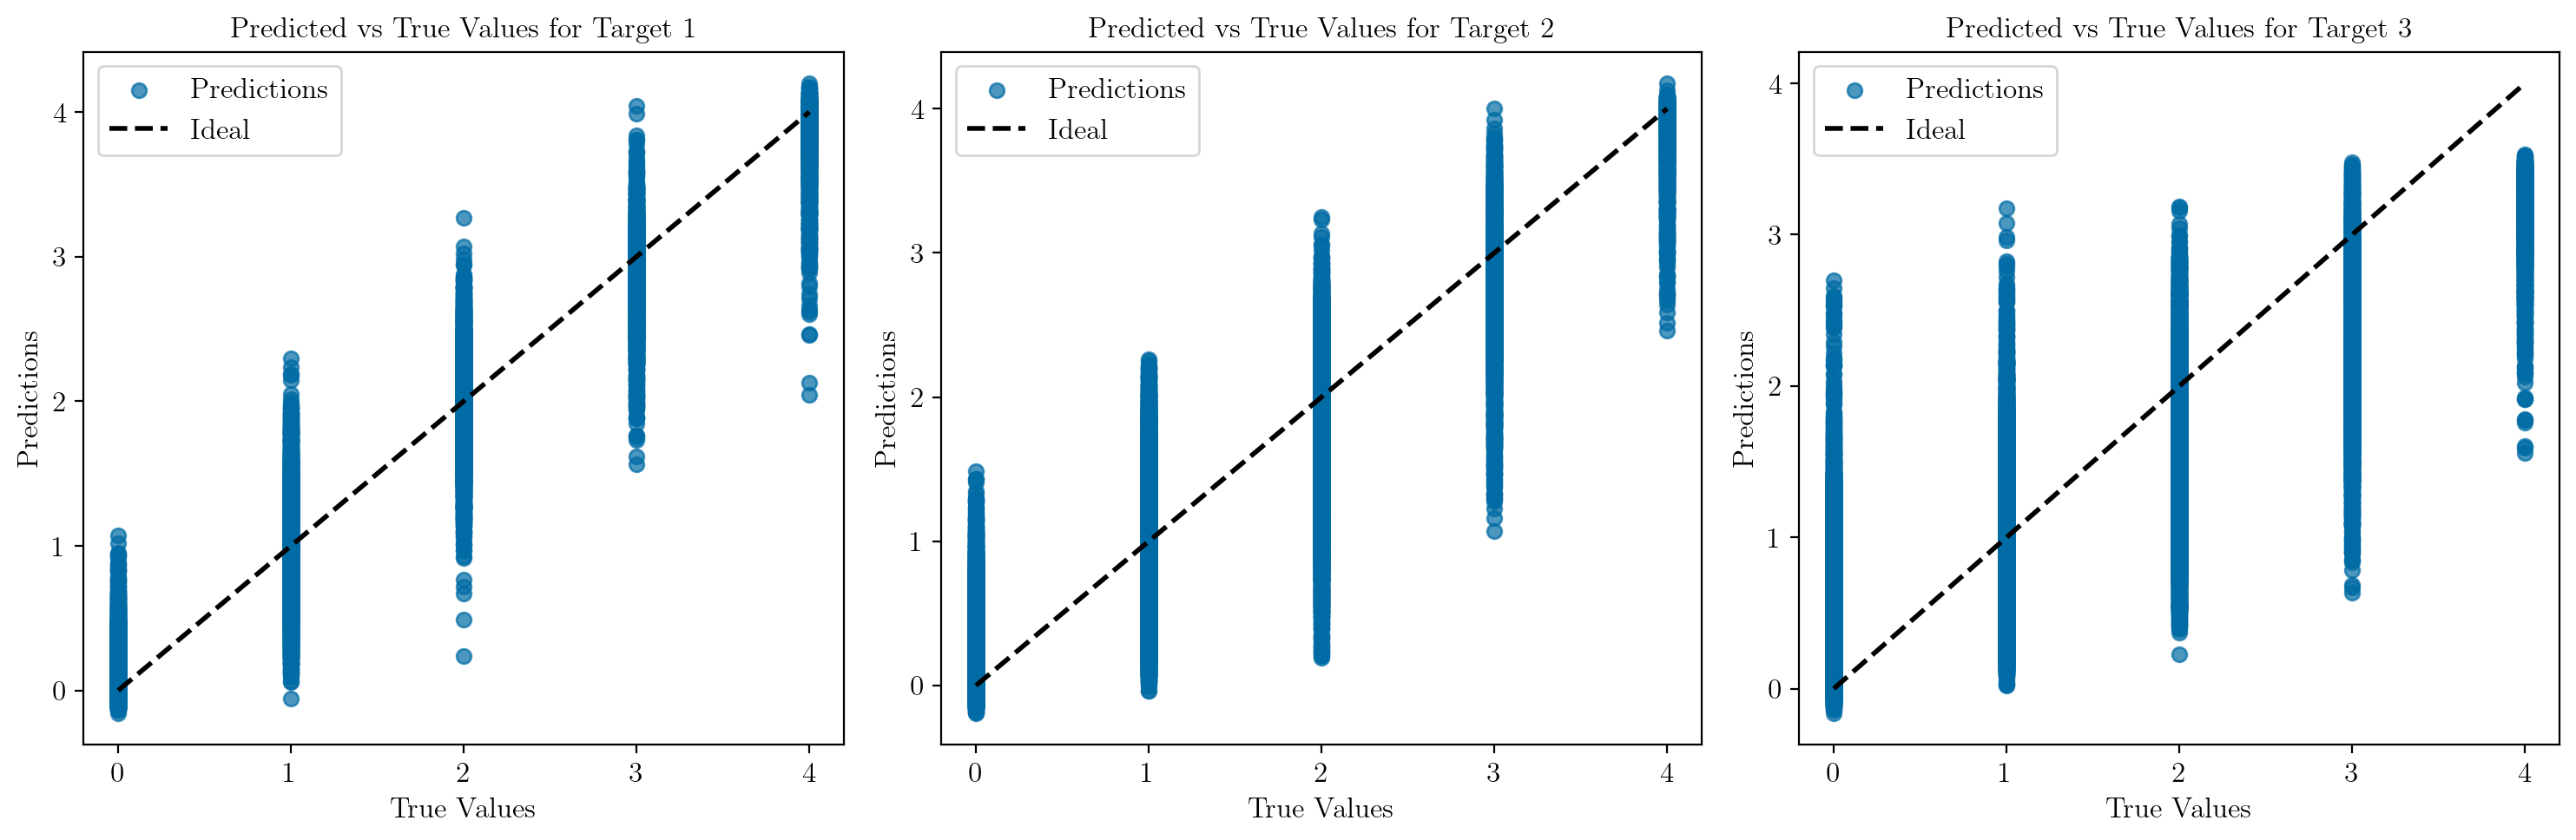

In [4]:

# Aggregate plots for data uncertainty
plt.figure(figsize=(15, 5))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    sns.histplot(data_uncertainty[:, i], kde=True, bins=30, color='red')
    plt.title(f"Data Uncertainty for Target {i+1}")
    plt.xlabel("Uncertainty")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Aggregate plots for knowledge uncertainty
plt.figure(figsize=(15, 5))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    sns.histplot(knowledge_uncertainty[:, i], kde=True, bins=30, color='blue')
    plt.title(f"Knowledge Uncertainty for Target {i+1}")
    plt.xlabel("Uncertainty")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Aggregate scatter plots for predictions vs. true values
plt.figure(figsize=(15, 5))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    plt.scatter(y_test[:, i], preds[:, i], alpha=0.7, label="Predictions")
    plt.plot([y_test[:, i].min(), y_test[:, i].max()], [y_test[:, i].min(), y_test[:, i].max()], 'k--', lw=2, label="Ideal")
    plt.title(f"Predicted vs True Values for Target {i+1}")
    plt.xlabel("True Values")
    plt.ylabel("Predictions")
    plt.legend()
plt.tight_layout()
plt.show()

# Uncer vs MSE

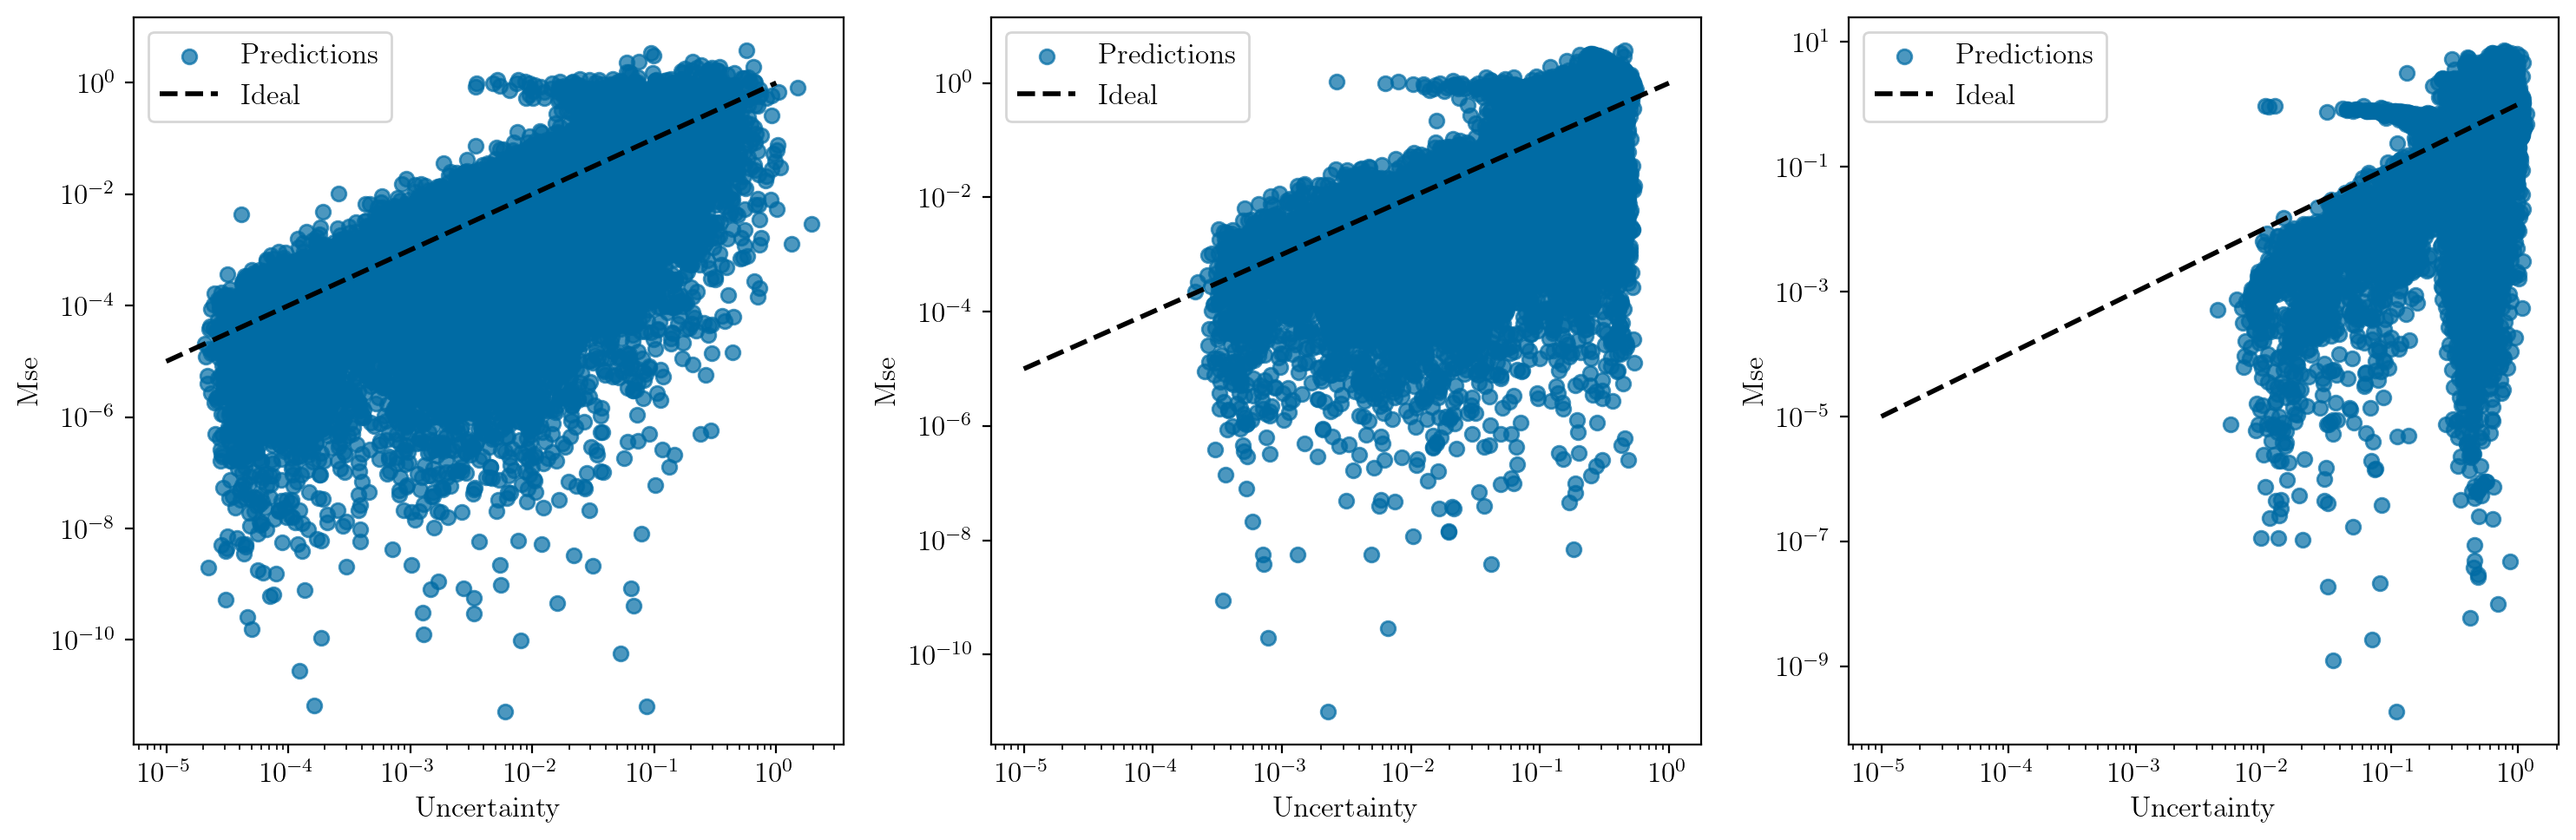

In [5]:
# Aggregate scatter plots for predictions vs. true values
plt.figure(figsize=(15, 5))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    plt.scatter(data_uncertainty[:, i], (y_test[:, i]- preds[:, i])**2, alpha=0.7, label="Predictions")
    # plt.errorbar(y_test[:, i], preds[:, i], xerr=data_uncertainty[:, i],alpha=0.7, label="Predictions", fmt=".")
    plt.plot([1e-5,1 ], [1e-5,1], 'k--', lw=2, label="Ideal")
    # plt.title(f"Predicted vs True Values for Target {i+1}")
    plt.xlabel("Uncertainty")
    plt.ylabel("Mse")
    plt.legend()
    plt.yscale("log")
    plt.xscale("log")
plt.tight_layout()
plt.show()

# Training Threshold

In [12]:
preds_train = []
data_uncertainty_train = []
knowledge_uncertainty_train = []

preds_test = []
data_uncertainty_test = []
knowledge_uncertainty_test = []

for i in range(y_train.shape[1]):
    
    model = models[i]

    # Generate predictions with uncertainty
    pred_train = model.virtual_ensembles_predict(X_train_new[::10], prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds_train.append(pred_train[:, 0])  # Mean predictions
    data_uncertainty_train.append(pred_train[:, 2])  # Data uncertainty
    knowledge_uncertainty_train.append(pred_train[:, 1])  # Knowledge uncertainty

    pred_test = model.virtual_ensembles_predict(X_test_new, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds_test.append(pred_test[:, 0])  # Mean predictions
    data_uncertainty_test.append(pred_test[:, 2])  # Data uncertainty
    knowledge_uncertainty_test.append(pred_test[:, 1])  # Knowledge uncertainty

# Convert lists to arrays for easier manipulation
preds_train = np.column_stack(preds_train)
data_uncertainty_train = np.column_stack(data_uncertainty_train)
knowledge_uncertainty_train = np.column_stack(knowledge_uncertainty_train)

preds_test = np.column_stack(preds_test)
data_uncertainty_test = np.column_stack(data_uncertainty_test)
knowledge_uncertainty_test = np.column_stack(knowledge_uncertainty_test)

In [13]:
optimized_thresholds = optimize_thresholds(preds_train, y_train[::10], class_to_poles)
print("Optimized Thresholds:", optimized_thresholds)

Optimization result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -0.43393650793650795
             x: [ 4.984e-01  4.986e-01 ...  4.893e-01  3.400e-01]
           nit: 304
          nfev: 697
 final_simplex: (array([[ 4.984e-01,  4.986e-01, ...,  4.893e-01,
                         3.400e-01],
                       [ 4.984e-01,  4.986e-01, ...,  4.893e-01,
                         3.400e-01],
                       ...,
                       [ 4.984e-01,  4.986e-01, ...,  4.893e-01,
                         3.400e-01],
                       [ 4.984e-01,  4.986e-01, ...,  4.893e-01,
                         3.400e-01]]), array([-4.339e-01, -4.339e-01, ..., -4.339e-01, -4.339e-01]))
Optimized Thresholds: [0.49844496 0.49862112 0.50043293 0.4976068  0.50471685 0.49674431
 0.50942553 0.49893137 0.5047553  0.50341231 0.49801561 0.51364543
 0.50089862 0.50488657 0.52105502 0.50615526 0.50637631 0.50922677
 0.50748881 0.49200

In [14]:
adjusted_preds_train = round_with_thresholds(preds_train, optimized_thresholds, class_to_poles)

res_ = np.sum(np.sum(np.round(preds_train) == y_train[::10], axis=1) == 3)/y_train.shape[0]
print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

res_ = np.sum(np.sum(adjusted_preds_train == y_train[::10], axis=1) == 3)/y_train.shape[0]
print(f"Test Accuracy Improved: {np.mean(res_):.4f}")

Test Accuracy Baselie: 0.0401
Test Accuracy Improved: 0.0434


In [21]:
adjusted_preds = round_with_thresholds(preds, optimized_thresholds, class_to_poles)

res_ = np.sum(np.sum(np.round(preds) == y_test, axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

res_ = np.sum(np.sum(adjusted_preds == y_test, axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy: {np.mean(res_):.4f}")

Test Accuracy Baselie: 0.3993
Test Accuracy: 0.4317


# Removing

/tmp/ipykernel_11512/2322663743.py:22: RuntimeWarning: invalid value encountered in scalar divide
  acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]


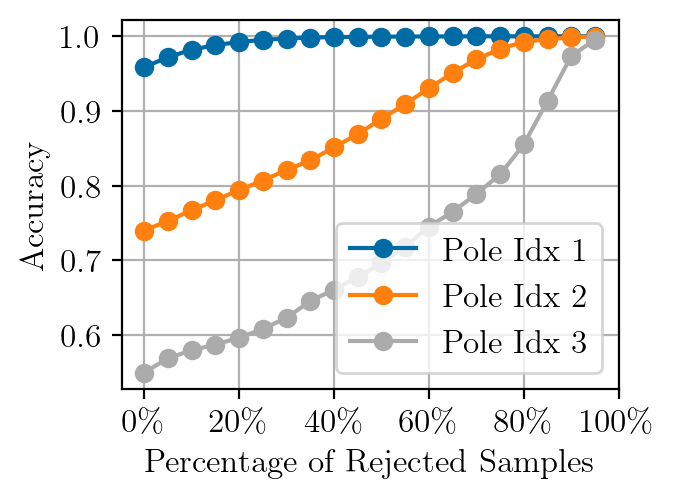

In [16]:
# Sort the data by uncertainty for each target
mse_changes = []
percent_removed = []

for i in range(y_train.shape[1]):
    sorted_indices = np.argsort(data_uncertainty[:, i])[::-1] 
    sorted_uncertainties = data_uncertainty[sorted_indices, i]
    sorted_true = y_test[sorted_indices, i]
    sorted_preds = preds[sorted_indices, i]

    # Calculate the MSE after removing samples with the highest uncertainty
    acc_list = []
    percent_list = []
    total_samples = len(sorted_uncertainties)

    for remove_percent in range(0, 101, 5):  # Remove in 5% increments
        num_remove = int(total_samples * (remove_percent / 100))
        remaining_true = sorted_true[num_remove:]
        remaining_preds = sorted_preds[num_remove:]

        # mse = np.mean((remaining_true - remaining_preds) ** 2)  # Calculate MSE
        acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]
        acc_list.append(acc)
        percent_list.append(remove_percent)
        

    mse_changes.append(acc_list)
    percent_removed.append(percent_list)

# Plot the results
# plt.figure(figsize=(15, 5))
fig, axs = plt.subplots(1,figsize=(3.54331, 3.54331*0.75))

for i in range(y_train.shape[1]):
    axs.plot(percent_removed[i], mse_changes[i],"-o", label=f"Pole Idx {i+1}")
axs.set_xlabel("Percentage of Rejected Samples")
axs.set_ylabel("Accuracy")
# axs.set_title("Impact of Removing High-Uncertainty Samples on Acc")
axs.legend()
axs.set_xticks([0, 20, 40, 60, 80, 100])
axs.set_xticklabels([f"{int(p)}\%" for p in [0, 20, 40, 60, 80, 100]])
axs.grid(True)
fig.tight_layout() # samples 
# fig.show()

# Hist

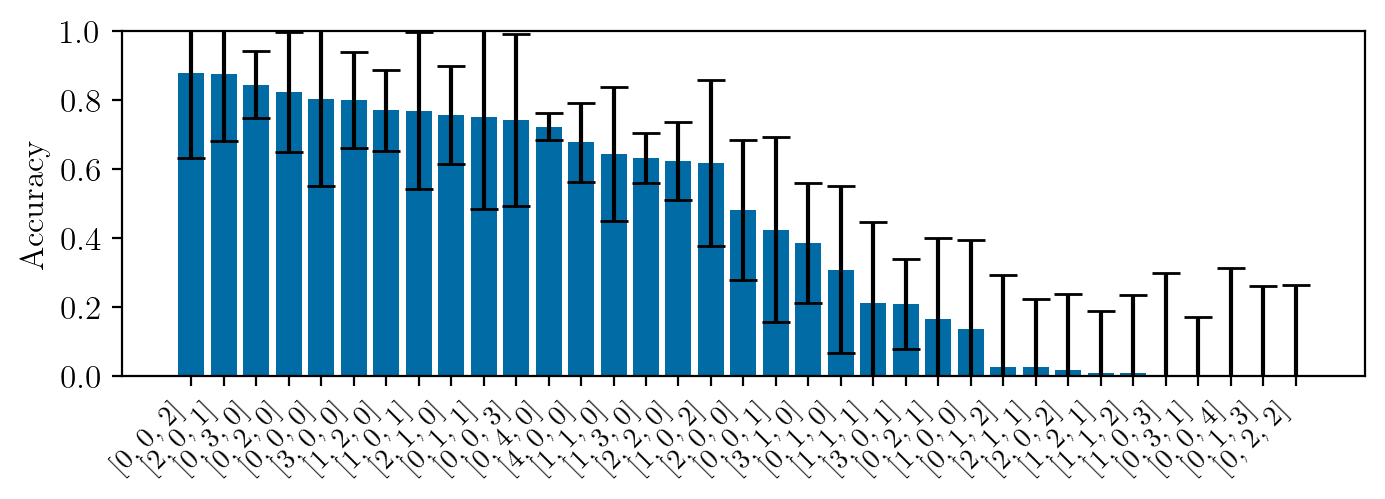

In [20]:
# Number of classes
num_classes = 35
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]
# Initialize an array to store accuracies for each class across folds
class_accuracies= []
class_uncer = []


for cls in range(num_classes):
    # Mask for the current class
    
    class_mask = (reconvert_labels(y_test, class_to_poles) == cls)
    # Calculate accuracy for the current fold and class
    # /np.sum(np.ones_like(y_test[:,0]))
    class_accuracy = np.sum(np.sum(adjusted_preds[class_mask]==y_test[class_mask],axis=1) == 3) / np.sum(class_mask)
    class_accuracies.append(class_accuracy)

    class_u = np.mean(data_uncertainty_test[class_mask])
    class_uncer.append(class_u)

class_accuracies = np.array(class_accuracies)
class_uncer = np.array(class_uncer)
# Bar plot with error bars
sorted_indices = np.argsort(class_accuracies)[::-1]
sorted_means = class_accuracies[sorted_indices]
sorted_stds = class_uncer[sorted_indices]
sorted_labels = [str(class_to_poles[i]) for i in sorted_indices]

# Plotting
fig, ax = plt.subplots(figsize=(3.54331*2, 3.54331*0.75))
ax.bar(range(num_classes), sorted_means, yerr=sorted_stds, capsize=5)
ax.set_ylabel('Accuracy')

ax.set_xticks(np.arange(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0,1)
# Adjust layout and show the plot
plt.tight_layout()
plt.show()